# Objectif du notebook 

Date de création :04/04/2026


Objectif : étudier la sensibilité de la distance $\theta$ utilisée jusqu'ici pour quantifier la similarité de deux vecteurs de RTFs. Cette étude est motivée par les résultats obtenus sur la séquence 144 tractée. Sur cette séquence (cas logiquement très favorable) une très faible similarité (au regard de la distance $\theta$) est observée entre vecteurs de RTFs associés à des positions successives. En revanche, le module et la phase présentent certains motifs continus dans le plan fréquence, numéro de réplique. Ceci suggère une certaine similarité des répliques d'une position à l'autre. La faible similarité quantifiée par un angle hermitien important résulte donc a priori davantage de l'inadéquation de la métrique utilisée que des variations trop rapides du vecteur de RTF.

Afin de mieux comprendre le comportement de la distance $\theta$ largement utilisée dans la littérature, on se propose ici d'étudier la sensibilité de la méthode à différentes altération du vecteur de RTF. Pour se faire on s'intéresse au comportement de $\theta$ vis à vis de deux types d'altérations : 

* **Ajout d'un bruit d'estimation**. Ce cas correspond au cas d'étude généralement considéré dans la littérature où l'objectif est de quantifier les performances de l'estimateur du vecteur de RTF. Dans ce cas, si l'estimateur est non biaisé, l'estimation du vecteur de RTF s'écrit $$ \hat{\Pi}(f) = \Pi(f) + e(f) $$ où $e(f)$ désigne l'erreur d'estimation à la fréquence $f$. 
* **Décalage fréquentiel du vecteur de RTF**. D'après les observations réalisées sur les données Fiberscope Groix et en simulation, le rapport des fonctions de transfert semble présenter des motifs caractéristiques qui évolue de manière continue avec la position. Ainsi, le passage d'une position à la suivante s'effectue en appliquant une déformation au vecteur de RTF. On considérera dans un premier temps le cas simple où la déformation est une simple translation le long de l'axe des fréquences. Ce cas correspond au cas où les motifs dans le plan fréquence, distance sont des droites. 
  

In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar

# Étape 1 : Chargement d'un vecteur de RTF

Dans le cas des essais Fiberscope dans le bassin Ifremer l'estimation CS-EVD coïncide parfaitement avec l'estimation par déconvolution. 

On charge donc un vecteur de RTF de cette série d'essais. Plus précisément on considère le vecteur de RTF estimer à partir des émissions statiques sur la position P1.   

In [4]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\static\09-10-2024T10-34-58-394627_P1_N1_Sweep_34_rtf.nc"
ds_rtf = xr.open_dataset(fpath)

In [5]:
ds_rtf

<xarray.Dataset> Size: 82MB
Dimensions:        (h_index: 5, time: 584000, ff: 8193, tt: 73, t_ir: 40001,
                    f_ir: 7000, f_rtf: 5734, f_csdm: 5734, h_index_bis: 5)
Coordinates:
  * h_index        (h_index) int32 20B 1 2 3 4 5
  * time           (time) float64 5MB 0.0 2.5e-05 5e-05 ... 14.6 14.6 14.6
  * ff             (ff) float64 66kB 0.0 2.441 4.883 7.324 ... 2e+04 2e+04 2e+04
  * tt             (tt) float64 584B 0.0 0.2048 0.4096 ... 14.34 14.54 14.75
  * t_ir           (t_ir) float64 320kB 0.0 2.5e-05 5e-05 ... 0.9999 1.0 1.0
  * f_ir           (f_ir) float64 56kB 8.001e+03 8.002e+03 ... 1.5e+04 1.5e+04
  * f_rtf          (f_rtf) float64 46kB 8e+03 8.002e+03 ... 1.5e+04 1.5e+04
  * f_csdm         (f_csdm) float64 46kB 8e+03 8.002e+03 ... 1.5e+04 1.5e+04
  * h_index_bis    (h_index_bis) int32 20B 1 2 3 4 5
Data variables:
    signal         (h_index, time) float64 23MB ...
    stft_amp       (h_index, ff, tt) float64 24MB ...
    stft_phase     (h_index, ff, tt) float64 24MB ...
    ri_hat         (h_index, t_ir) float64 2MB ...
    tf_hat_amp     (h_index, f_ir) float64 280kB ...
    tf_hat_phase   (h_index, f_ir) float64 280kB ...
    rtf_amp_hat    (h_index, f_rtf) float64 229kB ...
    rtf_phase_hat  (h_index, f_rtf) float64 229kB ...
    Rx             (f_csdm, h_index, h_index_bis) float64 1MB ...
    Rv             (f_csdm, h_index, h_index_bis) float64 1MB ...
    rtf_amp        (h_index, f_ir) float64 280kB ...
    rtf_phase      (h_index, f_ir) float64 280kB ...
Attributes: (12/14)
    Freq. ech:         200000,000000
    Freq. ech. Unité:  Hz
    Gamme:             1
    Gamme Unité:       V
    wf_increment:      4.999999999999959e-06
    wf_start_offset:   0.0
    ...                ...
    ts:                2.4999999999999795e-05
    fs:                40000.00000000033
    recording_name:    09-10-2024T10-34-58-394627_P1_N1_Sweep_34
    root_data:         C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_dat...
    img_path:          C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_dat...
    h_index_ref:       5

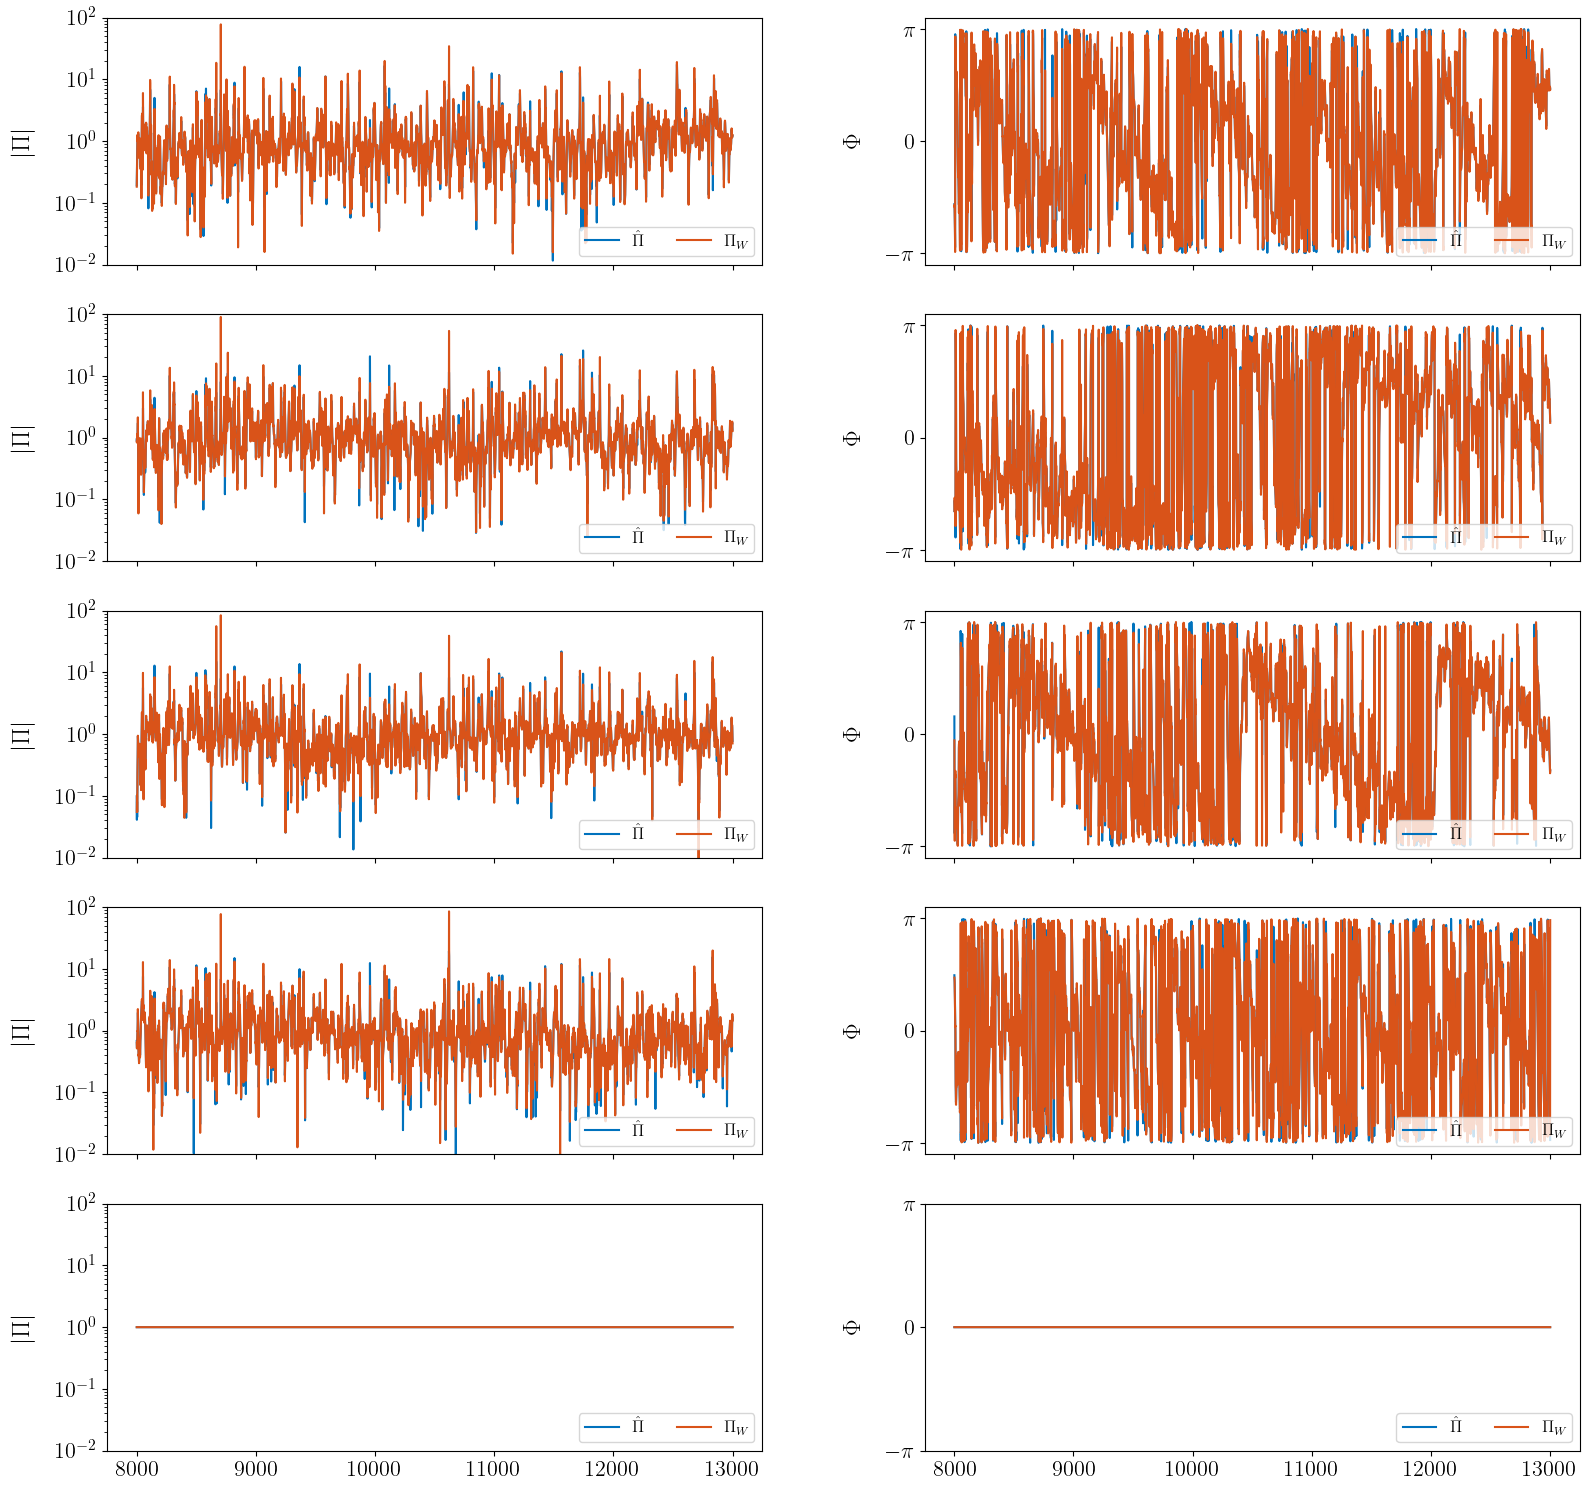

In [6]:
# fig, ax = plt.subplots(nrow=rtf_dyn.sizes["h_index"], sharex=True)
fmin = 8000
fmax = 13000

n_rcv = ds_rtf.h_index.size

fig, axs = plt.subplots(nrows=n_rcv, ncols=2, sharex=True, figsize=(16, 3 * n_rcv))
ax_mod, ax_phase = axs[:, 0], axs[:, 1]

for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    # Module
    ds_rtf.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv], color=color(0), label=r"$\hat{\Pi}$"
    )
    ds_rtf.rtf_amp.sel(h_index=h_plot).sel(f_ir=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv],
        color=color(1),
        label=r"$\Pi_{W}$",
    )

    ax_mod[i_rcv].set_ylim([0.01, 100])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$\lvert \Pi \rvert$")
    ax_mod[i_rcv].set_title("")
    ax_mod[i_rcv].legend(fontsize=12, ncol=2, loc="lower right")

    # Phase
    ds_rtf.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_phase[i_rcv], color=color(0), label=r"$\hat{\Pi}$"
    )
    ds_rtf.rtf_phase.sel(h_index=h_plot).sel(f_ir=slice(fmin, fmax)).plot(
        ax=ax_phase[i_rcv],
        color=color(1),
        label=r"$\Pi_{W}$",

    )

    ax_phase[i_rcv].set_xlabel("")
    ax_phase[i_rcv].set_ylabel(r"$\Phi$")
    ax_phase[i_rcv].set_title("")
    # Set yticks annotated in multiples of pi
    ax_phase[i_rcv].set_yticks([-np.pi, 0, np.pi])
    ax_phase[i_rcv].set_yticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax_phase[i_rcv].legend(fontsize=12, ncol=2, loc="lower right")

Comme évoqué ci-dessus les deux estimateurs coïncident ici parfaitement en module et en phase. 

# Étape 2 : étude du comportement de la distance $\theta$

Dans la suite on s'intéresse au comportement de la distance $\theta$ vis-à-vis des deux types d'altérations présenter en introduction. 

Le vecteur de RTF de référence est le vecteur estimé par la méthode CS-EVD pour la position et représenté ci-dessus.

In [66]:
# Define reference vector
# pi_ref = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)
pi = ds_rtf.rtf_amp_hat

# Limit the frequency range for simplicity
fmin = 10000
fmax = 13000
pi_ref = pi.sel(f_rtf=slice(fmin, fmax))

In [67]:
pi_ref

<xarray.DataArray 'rtf_amp_hat' (h_index: 5, f_rtf: 2458)> Size: 98kB
[12290 values with dtype=float64]
Coordinates:
  * h_index  (h_index) int32 20B 1 2 3 4 5
  * f_rtf    (f_rtf) float64 20kB 1e+04 1e+04 1e+04 ... 1.3e+04 1.3e+04 1.3e+04

## Effet du bruit d'estimation

On considère ici l'ajout d'un bruit d'estimation sur le vecteur de RTF. Ce bruit est un bruit gaussien. L'objectif est d'étudier les variations de l'angle hermitien moyen $\theta$ en fonction de la variance du bruit. 

*Remarque* : Markovich-Golan et al. 2018 compare les performances des estimateurs CS et CW et fourni des expressions analytique pour la variance de l'erreur d'estimation ($\theta_{CS} = \mathbb{E} \{ \lVert \Pi_{CS} - \Pi \rVert^2\}$). 

### Illustration 

In [68]:
h_index_ref = ds_rtf.h_index_ref
def add_noise(pi, sigma_noise):
    pi_noisy = pi + np.random.normal(loc=0, scale=sigma_noise, size=pi.shape)
    pi_noisy = np.abs(pi_noisy)
    pi_noisy.loc[dict(h_index=h_index_ref)] = 1
    return pi_noisy

In [69]:
# Un exemple rapide 
sigma_noise = 0.05
pi_noisy = add_noise(pi=pi_ref, sigma_noise=sigma_noise)


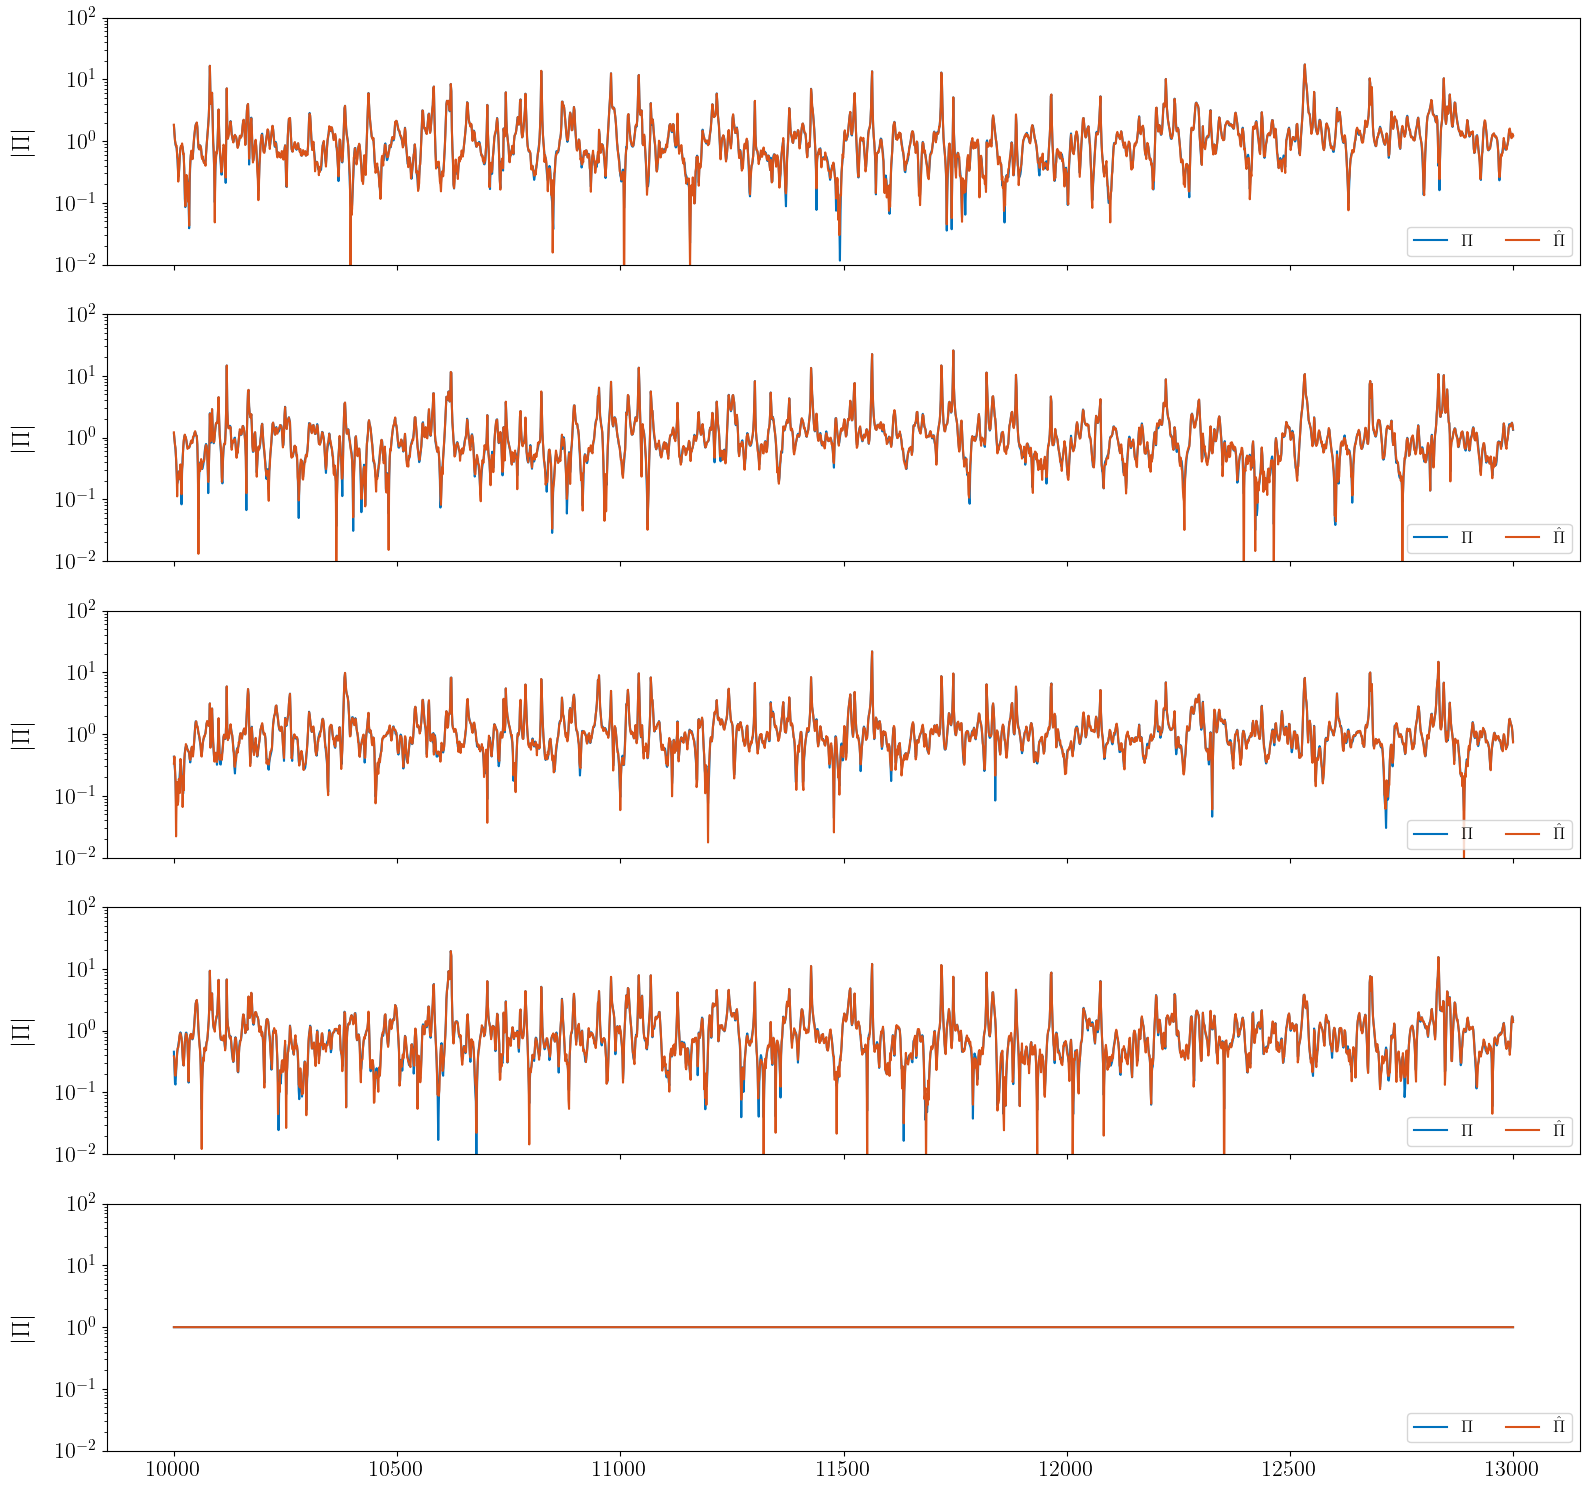

In [70]:
# fig, ax = plt.subplots(nrow=rtf_dyn.sizes["h_index"], sharex=True)


n_rcv = ds_rtf.h_index.size

fig, ax_mod = plt.subplots(nrows=n_rcv, ncols=1, sharex=True, figsize=(16, 3 * n_rcv))

for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    pi_ref.sel(h_index=h_plot).plot(
        ax=ax_mod[i_rcv], color=color(0), label=r"$\Pi$"
    )
    pi_noisy.sel(h_index=h_plot).plot(
        ax=ax_mod[i_rcv],
        color=color(1),
        label=r"$\hat{\Pi}$",
    )

    ax_mod[i_rcv].set_ylim([0.01, 100])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$\lvert \Pi \rvert$")
    ax_mod[i_rcv].set_title("")
    ax_mod[i_rcv].legend(fontsize=12, ncol=2, loc="lower right")

In [71]:
# Next we compute the hermitian angle
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

theta = D_hermitian_angle_fast(
    rtf_ref=pi_ref.values,
    rtf=pi_noisy.values,
    **dist_kwargs,
)

print(f"Hermitian angle {theta}°")

Hermitian angle 2.2296603564676047°


### Variation en fonction du niveau de bruit 

In [72]:
n = 5000
sigma_noise = np.linspace(0.0001, 3, num=n)

pi_corrupted = []
for sigma in sigma_noise:
    pi_noisy = add_noise(pi=pi_ref, sigma_noise=sigma)
    pi_corrupted.append(pi_noisy)

In [82]:
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

n_monte_carlo = 10
n = 10000
sigma_noise = np.linspace(0.01, 100, num=n)

theta = []
for i_mc in range(n_monte_carlo):

    pi_corrupted = []
    for sigma in sigma_noise:
        pi_noisy = add_noise(pi=pi_ref, sigma_noise=sigma)
        pi_corrupted.append(pi_noisy)

    dist = []

    for i in range(sigma_noise.size):

        d = D_hermitian_angle_fast(
            rtf_ref=pi_ref.values,
            rtf=pi_corrupted[i].values,
            **dist_kwargs,
        )
        dist.append(d)

    theta.append(dist)


theta = np.array(theta)
theta_mean = np.mean(theta, axis=0)
theta_std = np.std(theta, axis=0)

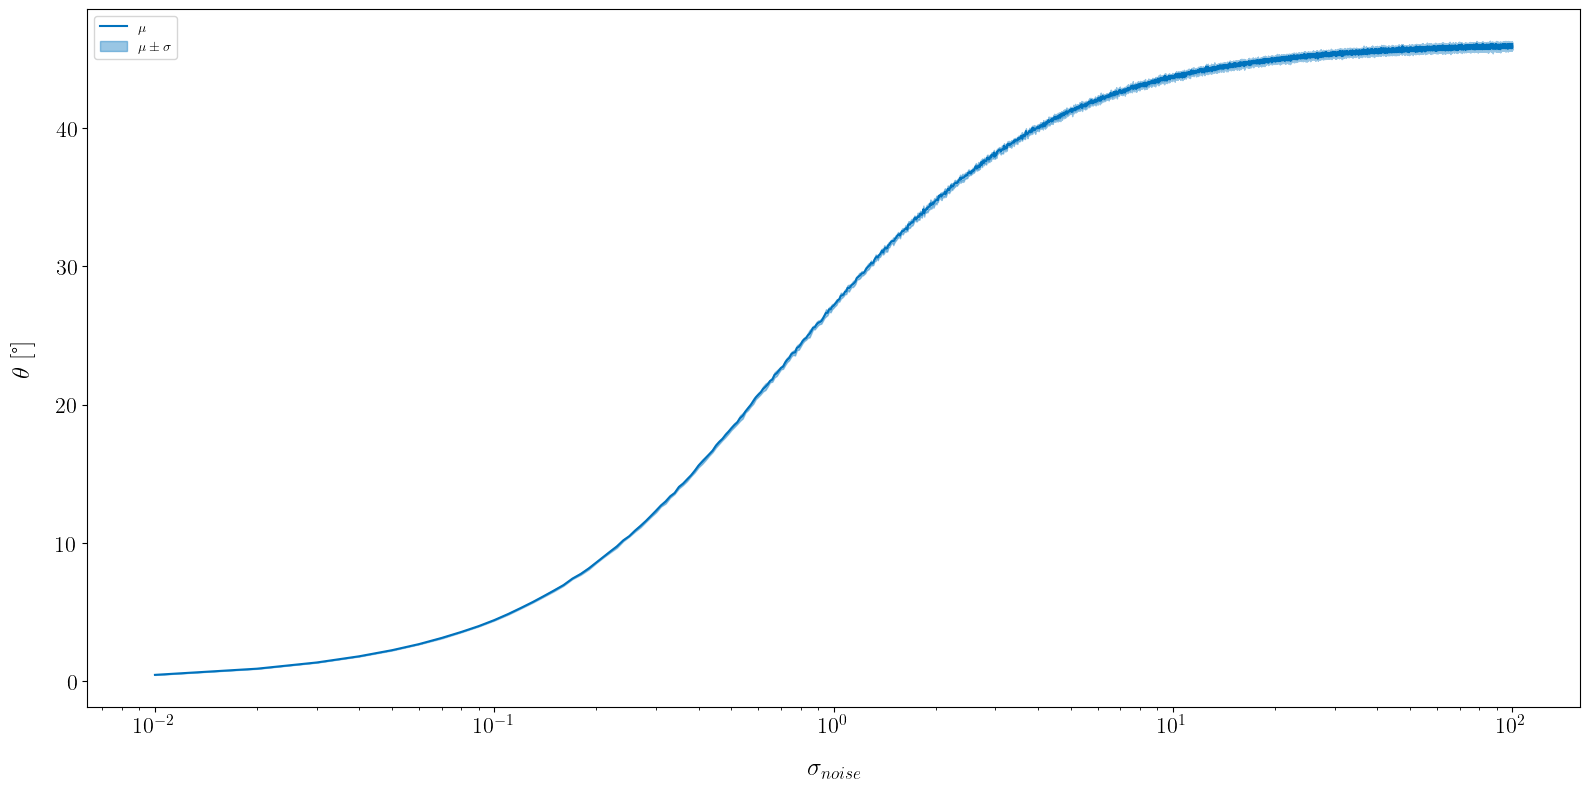

In [83]:
# Plot
plt.figure()

plt.plot(sigma_noise, theta_mean, color=color(0), label="$\mu$")
plt.fill_between(
    sigma_noise,
    theta_mean - theta_std,
    theta_mean + theta_std,
    color=color(0),
    alpha=0.4,
    label="$\mu \pm \sigma$",
)
plt.xlabel("$\sigma_{noise}$")
plt.ylabel(r"$\theta $ [°]")
plt.xscale("log")
plt.legend()

# # Plot
# plt.figure()

# plt.plot(sigma_noise, theta)
# plt.xlabel(r"$\sigma_{noise}$")
# plt.ylabel(r"$\theta $ [°]")
# plt.xscale("log")

In [81]:
# Un exemple rapide 
sigma_noise = 1
pi_noisy = add_noise(pi=pi_ref, sigma_noise=sigma_noise)


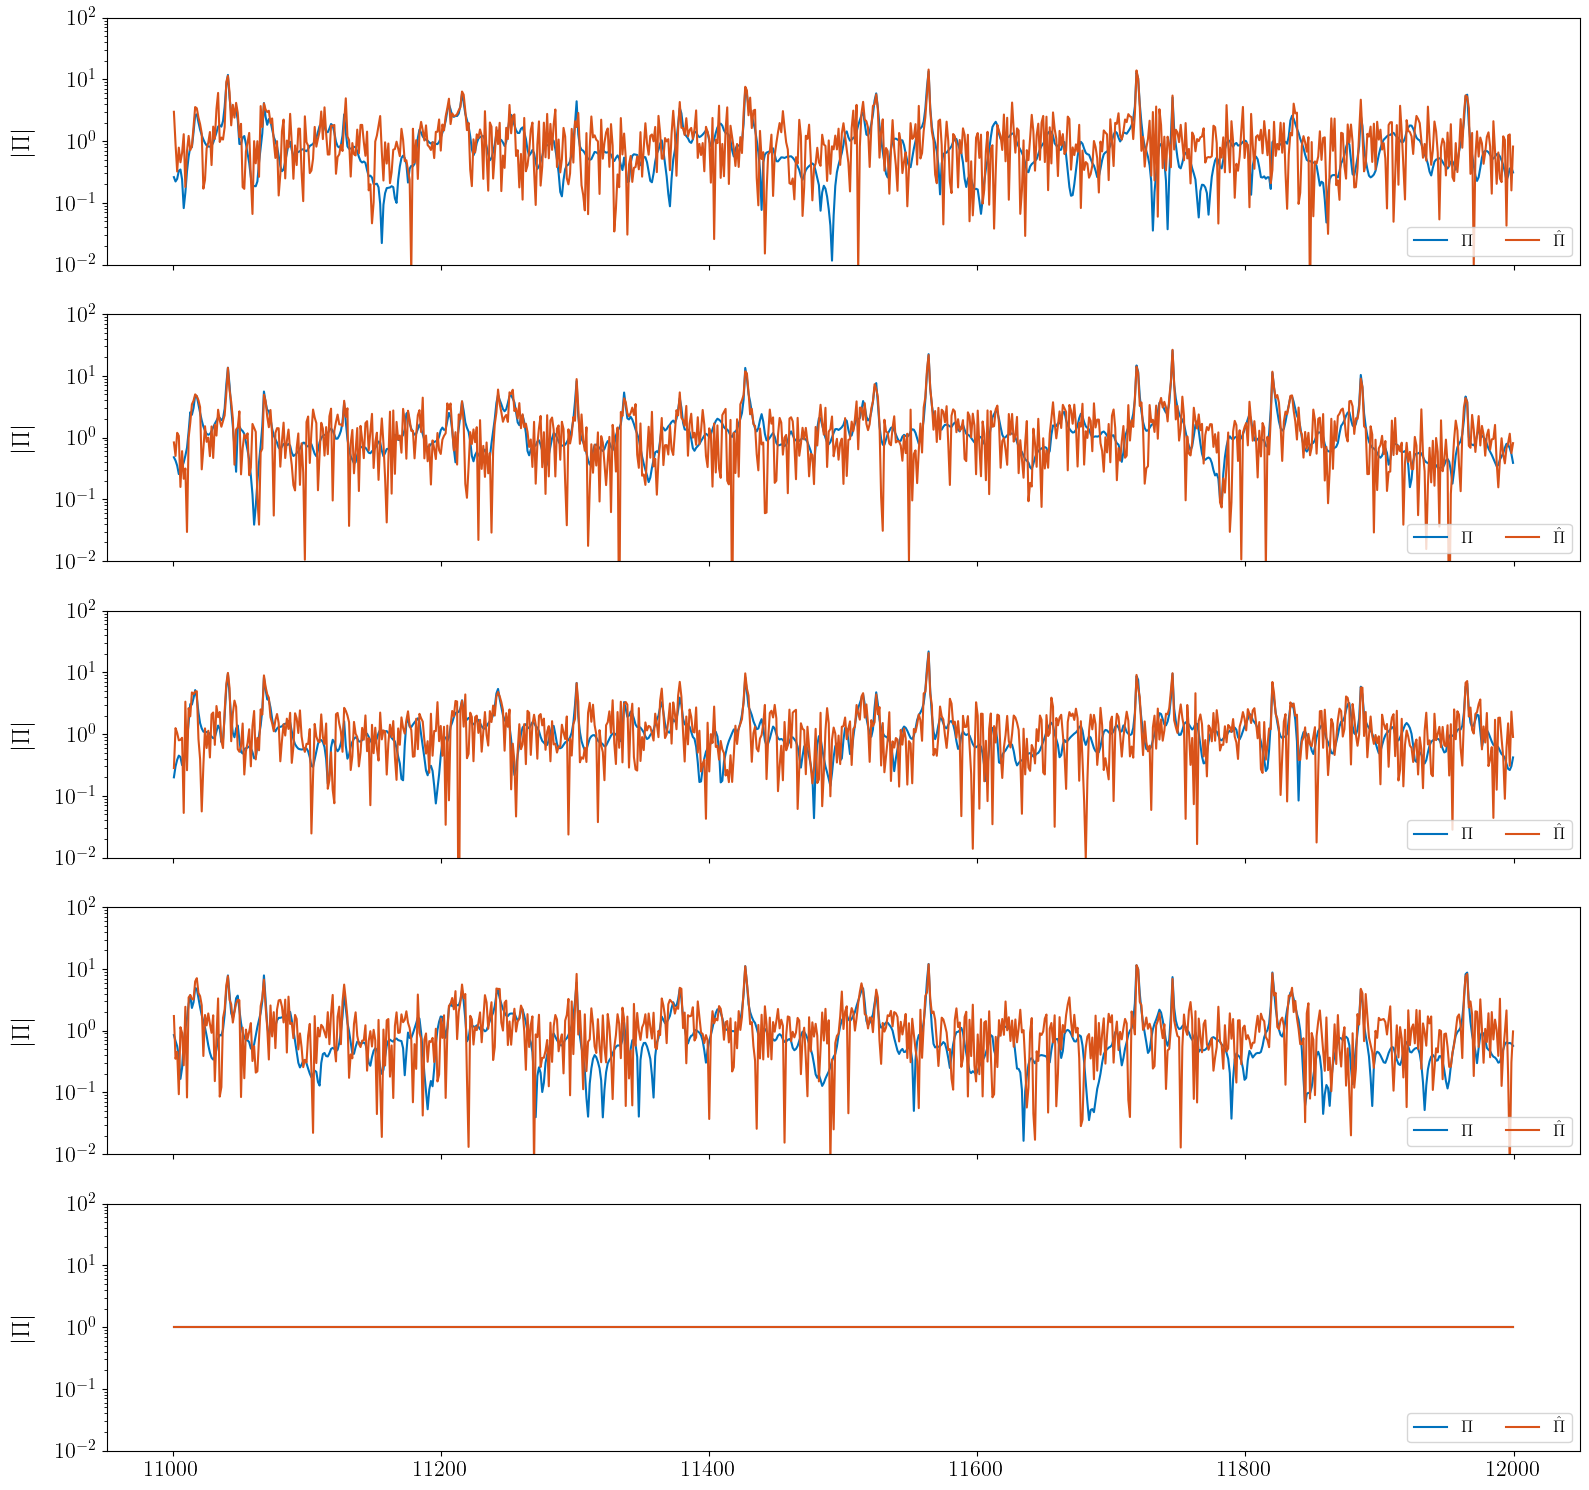

In [17]:
# fig, ax = plt.subplots(nrow=rtf_dyn.sizes["h_index"], sharex=True)
fmin = 11000
fmax = 12000

n_rcv = ds_rtf.h_index.size

fig, ax_mod = plt.subplots(nrows=n_rcv, ncols=1, sharex=True, figsize=(16, 3 * n_rcv))

for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    pi_ref.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv], color=color(0), label=r"$\Pi$"
    )
    pi_noisy.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv],
        color=color(1),
        label=r"$\hat{\Pi}$",
    )

    ax_mod[i_rcv].set_ylim([0.01, 100])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$\lvert \Pi \rvert$")
    ax_mod[i_rcv].set_title("")
    ax_mod[i_rcv].legend(fontsize=12, ncol=2, loc="lower right")

## Effet de distorsion

On s'intéresse ici à l'effet d'une distorsion des composantes du vecteur de RTF. 

Pour faire simple on se limite dans un premier temps au cas d'un shift du vecteur en fréquence. 

*Remarque* : Markovich-Golan et al. 2018 compare les performances des estimateurs CS et CW et fourni des expressions analytique pour la variance de l'erreur d'estimation ($\theta_{CS} = \mathbb{E} \{ \lVert \Pi_{CS} - \Pi \rVert^2\}$). 

### Illustration 

In [18]:
def shift_rtf(pi, n_shift):    
    pi_shifted = pi.roll(f_rtf=n_shift)
    return pi_shifted

In [19]:
# Un exemple rapide
n_shift = 3
pi_shifted = shift_rtf(pi=pi_ref, n_shift=n_shift)

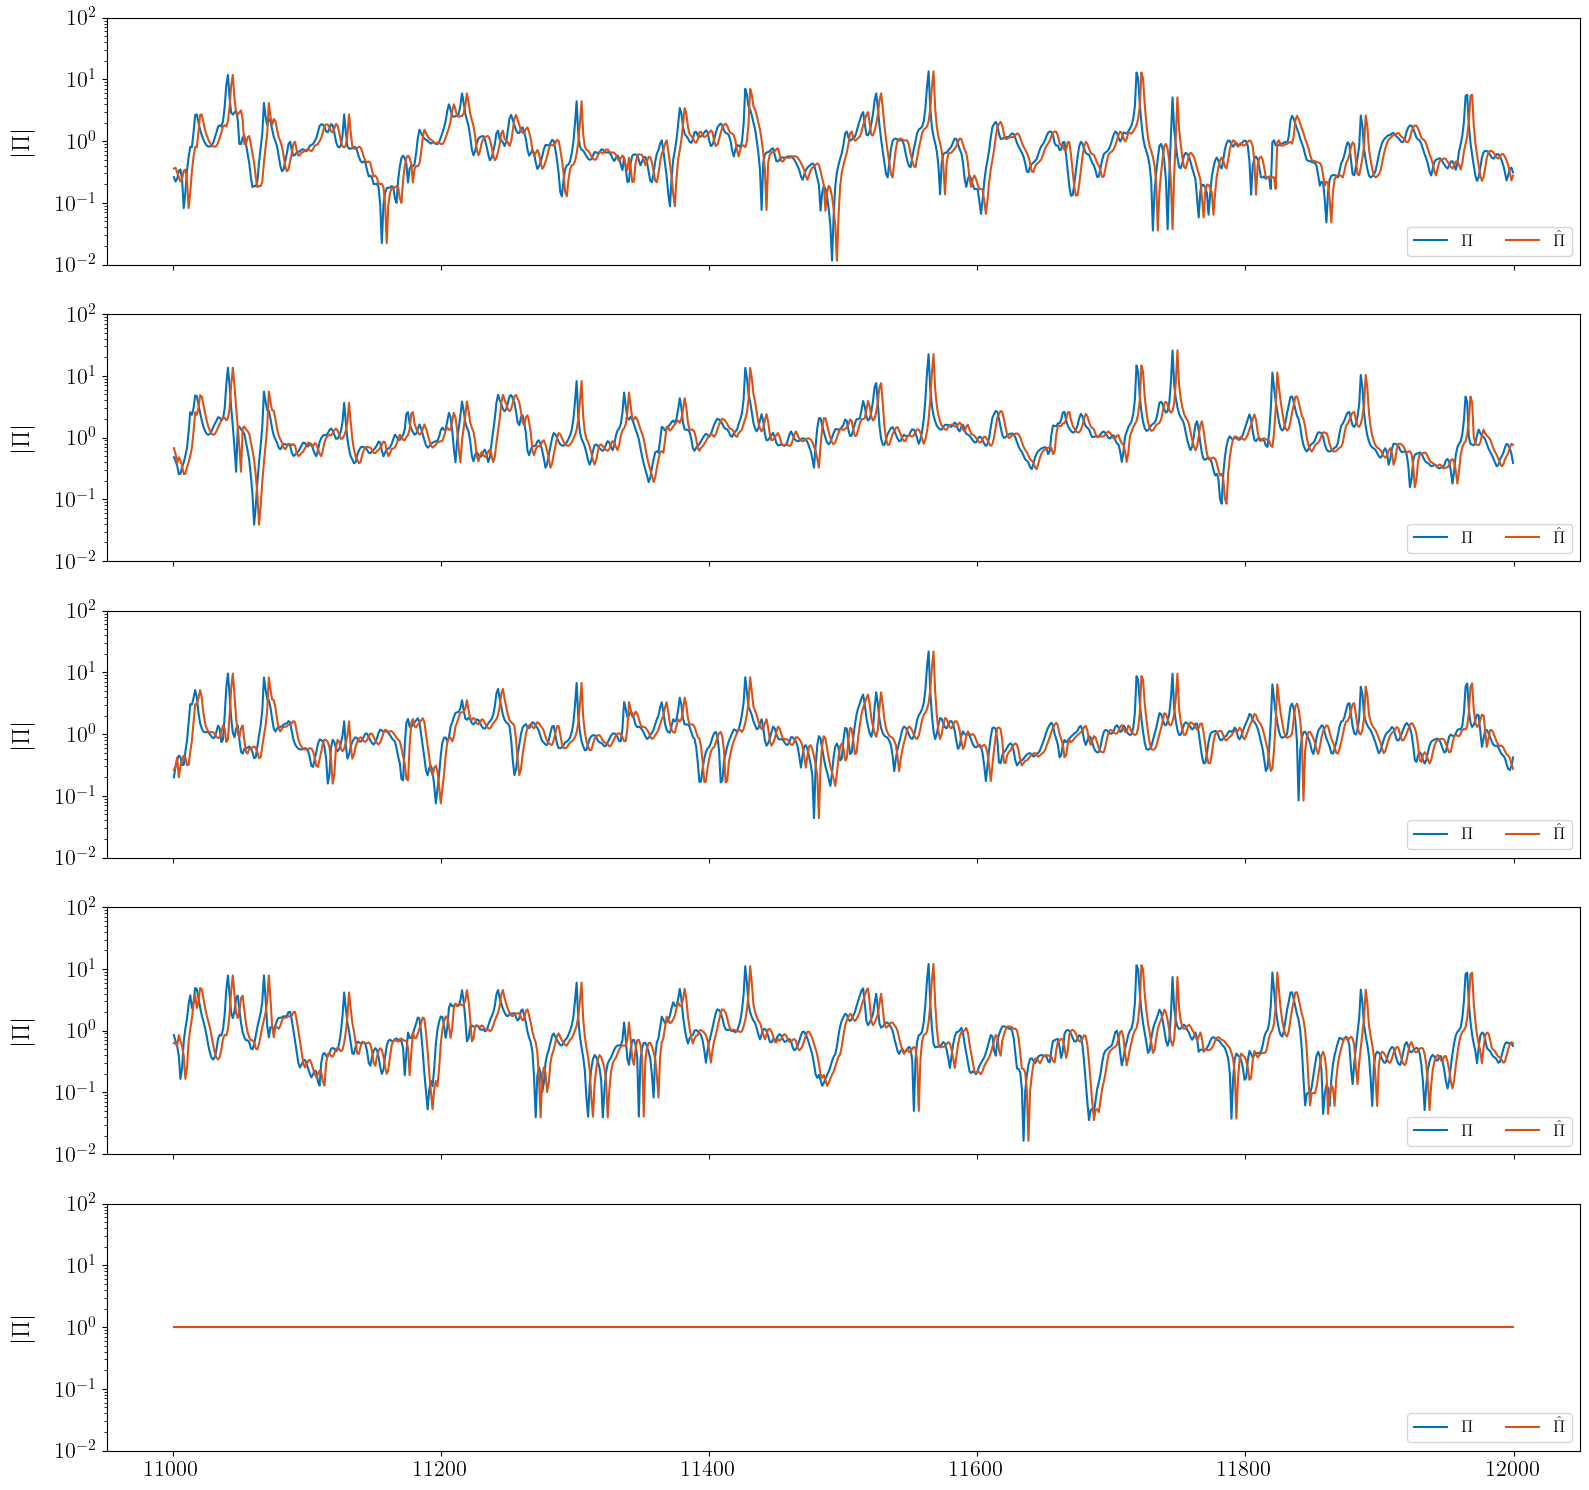

In [20]:
n_rcv = ds_rtf.h_index.size

fig, ax_mod = plt.subplots(nrows=n_rcv, ncols=1, sharex=True, figsize=(16, 3 * n_rcv))

for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    pi_ref.sel(h_index=h_plot).plot(
        ax=ax_mod[i_rcv], color=color(0), label=r"$\Pi$"
    )
    pi_shifted.sel(h_index=h_plot).plot(
        ax=ax_mod[i_rcv],
        color=color(1),
        label=r"$\hat{\Pi}$",
    )

    ax_mod[i_rcv].set_ylim([0.01, 100])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$\lvert \Pi \rvert$")
    ax_mod[i_rcv].set_title("")
    ax_mod[i_rcv].legend(fontsize=12, ncol=2, loc="lower right")

In [21]:
# Next we compute the hermitian angle
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

theta = D_hermitian_angle_fast(
    rtf_ref=pi_ref.values,
    rtf=pi_shifted.values,
    **dist_kwargs,
)

print(f"Hermitian angle {theta}°")

Hermitian angle 15.988536482352163°


Pour un décalage d'un unique bin fréquentiel les deux vecteurs de RTFs semblent visuellement très similaire néanmoins l'angle hermitien est très élevé. 

### Variation en fonction du shift

In [39]:
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

n_monte_carlo = 100
n_shift = np.arange(1, 100, 1)

theta = []
for i_mc in range(n_monte_carlo):
    pi_corrupted = []
    for shift in n_shift:
        pi_shifted = shift_rtf(pi=pi_ref, n_shift=shift)
        pi_corrupted.append(pi_shifted)

    dist = []

    for i in range(n_shift.size):

        d = D_hermitian_angle_fast(
            rtf_ref=pi_ref.values,
            rtf=pi_corrupted[i].values,
            **dist_kwargs,
        )
        dist.append(d)
    
    theta.append(dist)


theta = np.array(theta)
theta_mean_same_shift = np.mean(theta, axis=0)
theta_std_same_shift = np.std(theta, axis=0)

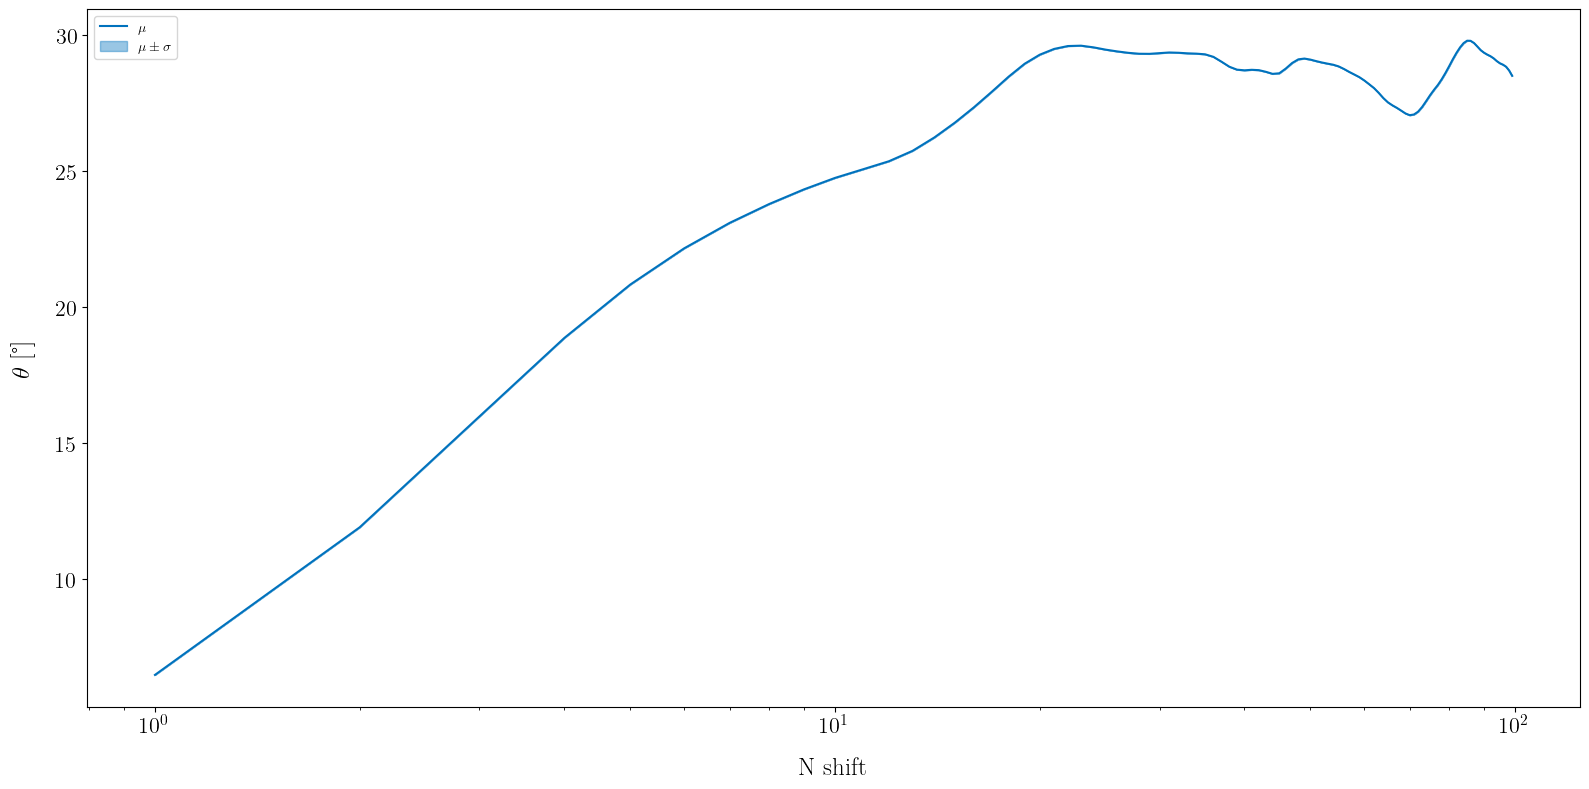

In [40]:
# Plot
plt.figure()

plt.plot(n_shift, theta_mean_same_shift, color=color(0), label=r"$\mu$")
plt.fill_between(
    n_shift,
    theta_mean_same_shift + theta_std_same_shift,
    theta_mean_same_shift - theta_std_same_shift,
    color=color(0),
    alpha=0.4,
    label="$\mu \pm \sigma$",
)
plt.xlabel(r"N shift")
plt.ylabel(r"$\theta $ [°]")
plt.xscale("log")
plt.legend()

Ce cas représente le cas le plus simple de distorsion du vecteur de RTF que l'on peut considérer. En pratique, dans les données Fiberscope en bassin et à Groix la distortion est beaucoup plus complexe. En particulier :

* L'opérateur de distorsion du vecteur de RTF n'est pas une simple opération de shift en fréquence. Chacune des structures du vecteur de RTF peut être shifté dans un sens ou un autre (en pratique la déformation n'est pas linéaire, les courbes dans le plan fréquence, réplique ne sont pas des droites mais on peut considérer que localement, d'une réplique à l'autre la déformation est linéaire). 
* D'autre part, la déformation appliqué n'est pas la même sur chaque composante du vecteur de RTF. 

In [56]:
def shift_rtf_2(pi, n_shift_max):    
    pi_shifted = pi.copy()
    # for h_i in pi.h_index.values:
    #     pi_shifted.loc[dict(h_index=h_i)] = pi_shifted.sel(h_index=h_i).roll(f_rtf=np.random.randint(low=0, high=n_shift_max+1))
    # return pi_shifted

    sign = [-1, 1]
    for h_i in pi.h_index.values:
        sign_idx = np.random.randint(low=0, high=2)
        pi_shifted.loc[dict(h_index=h_i)] = pi_shifted.sel(h_index=h_i).roll(f_rtf=sign[sign_idx]*n_shift_max)
    return pi_shifted

In [63]:
# Un exemple rapide
n_shift = 10
pi_shifted = shift_rtf_2(pi=pi_ref, n_shift_max=n_shift)

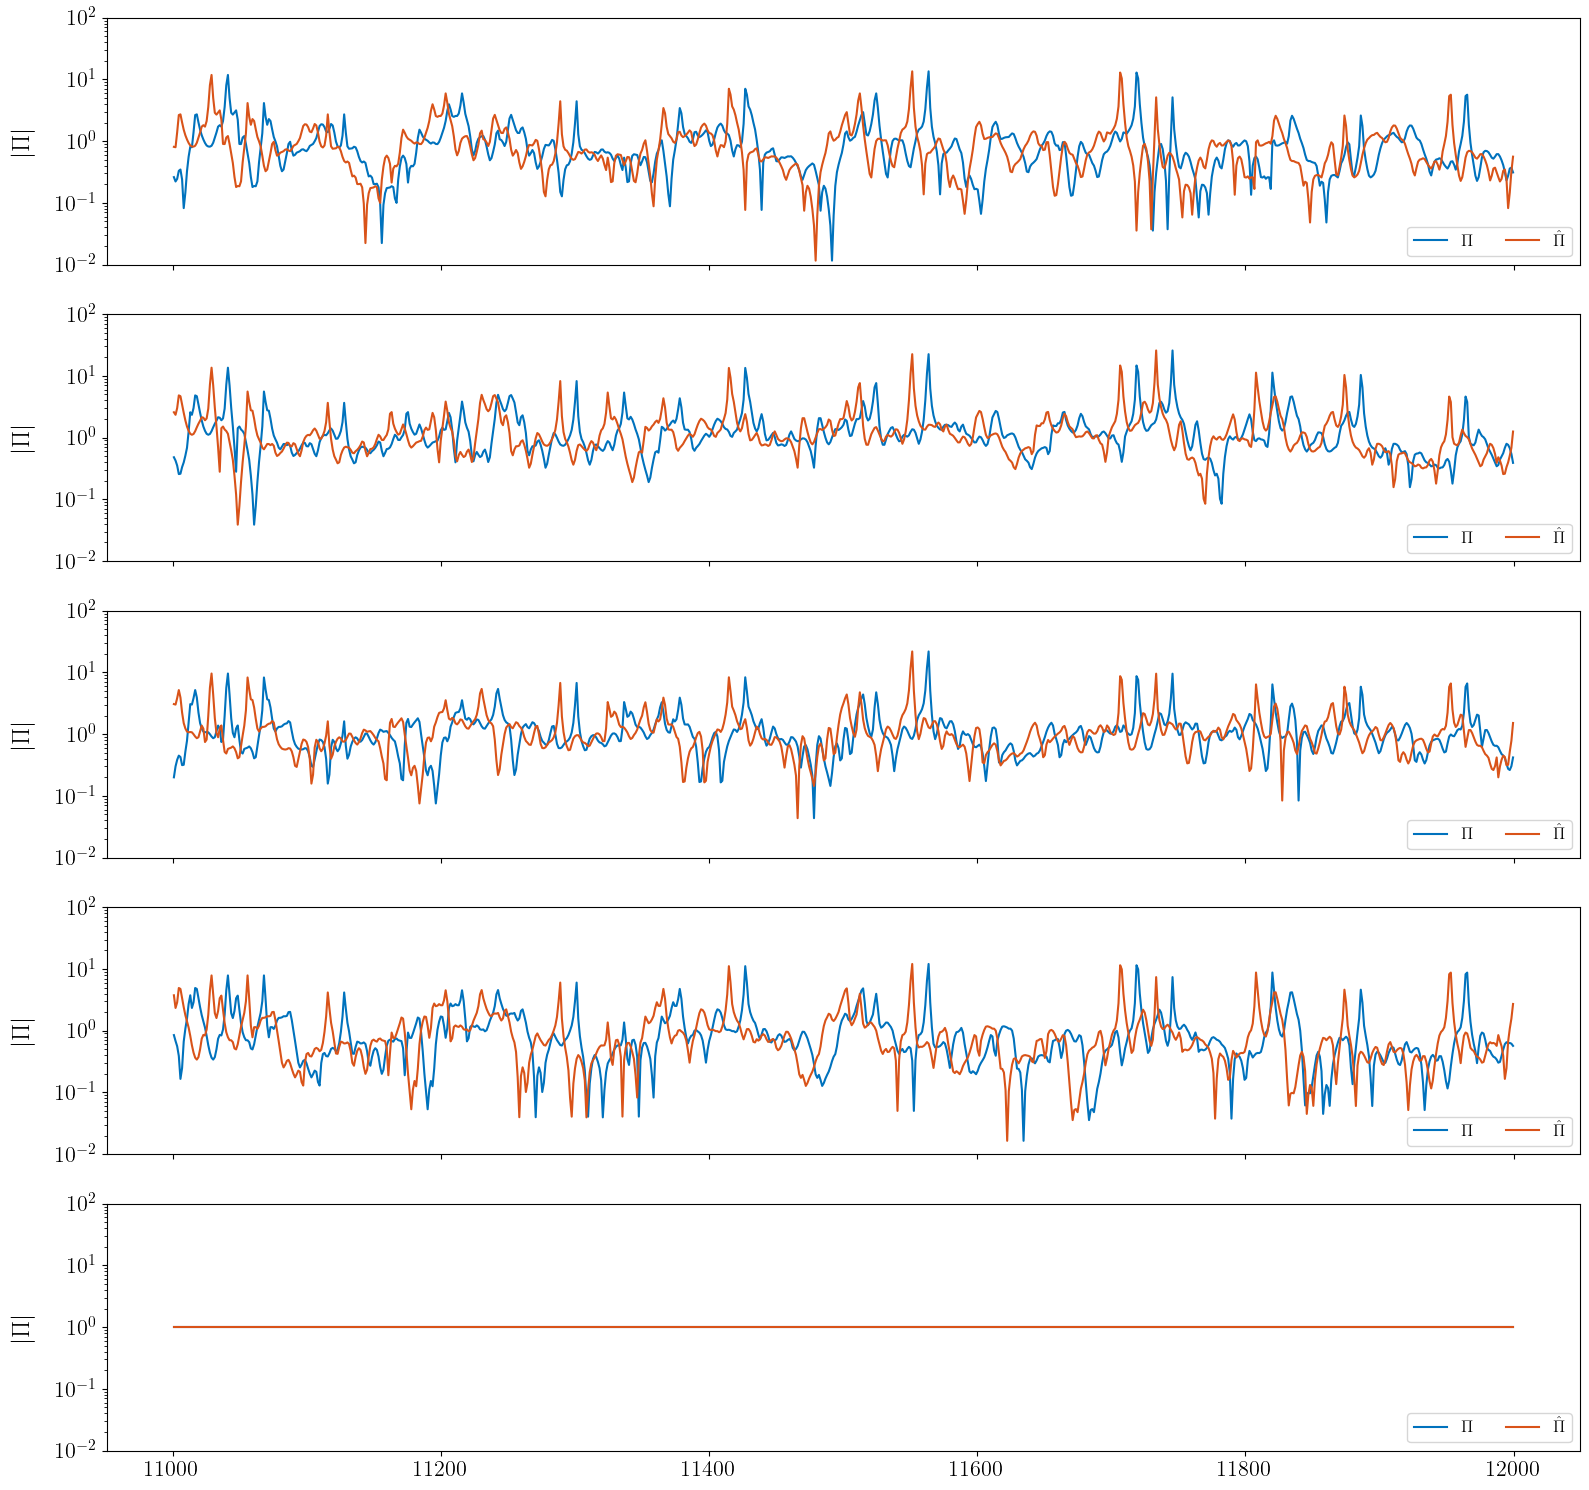

In [64]:
n_rcv = ds_rtf.h_index.size

fig, ax_mod = plt.subplots(nrows=n_rcv, ncols=1, sharex=True, figsize=(16, 3 * n_rcv))

for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    pi_ref.sel(h_index=h_plot).plot(
        ax=ax_mod[i_rcv], color=color(0), label=r"$\Pi$"
    )
    pi_shifted.sel(h_index=h_plot).plot(
        ax=ax_mod[i_rcv],
        color=color(1),
        label=r"$\hat{\Pi}$",
    )

    ax_mod[i_rcv].set_ylim([0.01, 100])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$\lvert \Pi \rvert$")
    ax_mod[i_rcv].set_title("")
    ax_mod[i_rcv].legend(fontsize=12, ncol=2, loc="lower right")

In [65]:
# Next we compute the hermitian angle
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

theta = D_hermitian_angle_fast(
    rtf_ref=pi_ref.values,
    rtf=pi_shifted.values,
    **dist_kwargs,
)

print(f"Hermitian angle {theta}°")

Hermitian angle 24.759126523523285°


In [60]:
dist_kwargs = {"ax_rcv": 0, "ax_f": 1, "apply_mean": True}

n_monte_carlo = 100
n_shift = np.arange(1, 100, 1)

theta = []
for i_mc in range(n_monte_carlo):
    pi_corrupted = []
    for shift in n_shift:
        pi_shifted = shift_rtf_2(pi=pi_ref, n_shift_max=shift)
        pi_corrupted.append(pi_shifted)

    dist = []

    for i in range(n_shift.size):

        d = D_hermitian_angle_fast(
            rtf_ref=pi_ref.values,
            rtf=pi_corrupted[i].values,
            **dist_kwargs,
        )
        dist.append(d)
    
    theta.append(dist)


theta = np.array(theta)
theta_mean_random_shift = np.mean(theta, axis=0)
theta_std_random_shift = np.std(theta, axis=0)

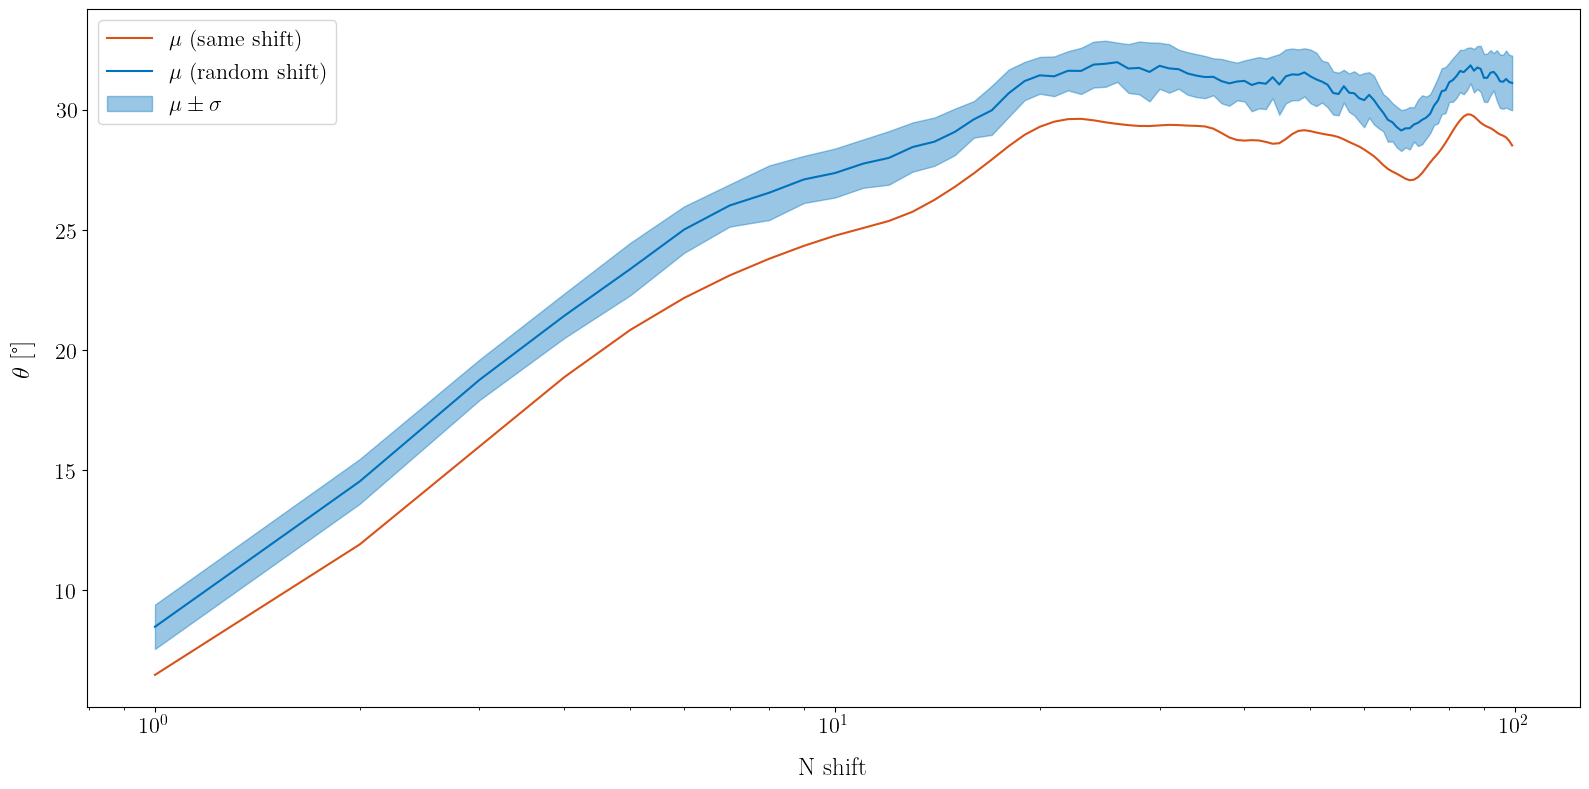

In [61]:
# Plot
plt.figure()
plt.plot(n_shift, theta_mean_same_shift, color=color(1), label=r"$\mu$ (same shift)")
plt.plot(n_shift, theta_mean_random_shift, color=color(0), label=r"$\mu$ (random shift)")
plt.fill_between(
    n_shift,
    theta_mean_random_shift - theta_std_random_shift,
    theta_mean_random_shift + theta_std_random_shift,
    color=color(0),
    alpha=0.4,
    label="$\mu \pm \sigma$",
)
plt.xlabel("N shift")
plt.ylabel(r"$\theta $ [°]")
plt.xscale("log")
plt.legend(fontsize=16)

In [62]:
shift = 10
df = ds_rtf.f_rtf.values[1] - ds_rtf.f_rtf.values[0]
shift_f = shift * df
print(f"n_shift bin freq = {shift} -> frequency shift {shift_f} Hz")

n_shift bin freq = 10 -> frequency shift 12.20703125 Hz
